<a href="https://colab.research.google.com/github/ranjanasri6/AGH-Internship-Journey/blob/main/classificationandregressionmodels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance (1).csv


In [ ]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
X_reg = df.drop("charges", axis=1)
y_reg = df["charges"]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

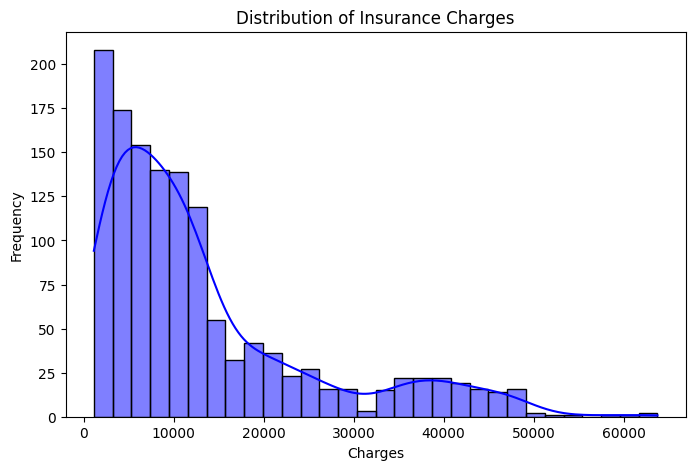

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True, color="blue")
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

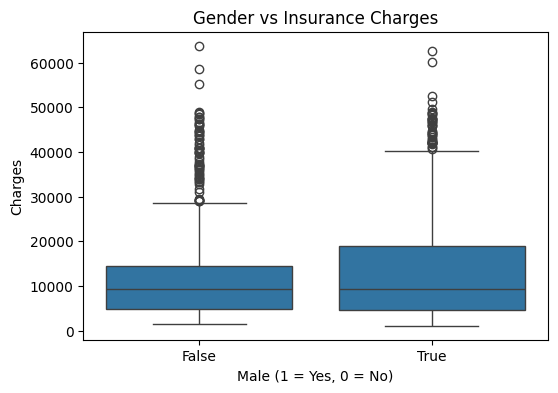

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="sex_male", y="charges", data=df)
plt.title("Gender vs Insurance Charges")
plt.xlabel("Male (1 = Yes, 0 = No)")
plt.ylabel("Charges")
plt.show()

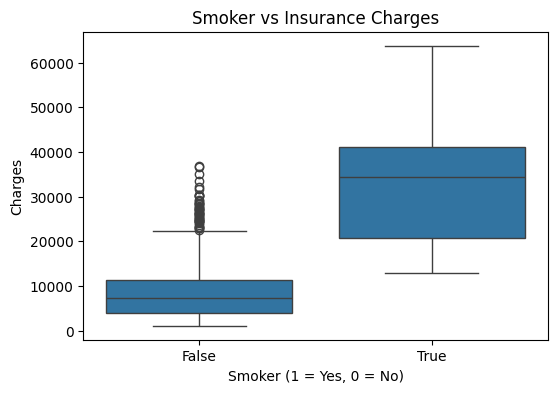

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker_yes", y="charges", data=df)
plt.title("Smoker vs Insurance Charges")
plt.xlabel("Smoker (1 = Yes, 0 = No)")
plt.ylabel("Charges")
plt.show()

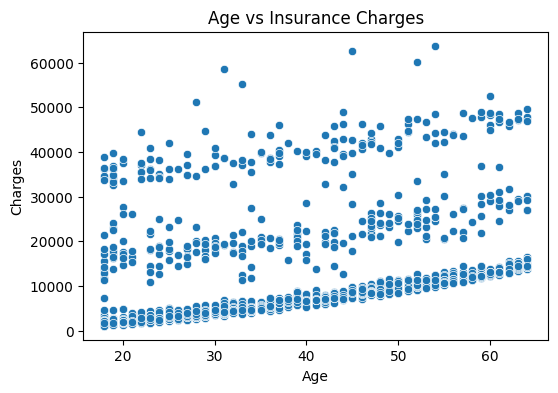

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"], y=df["charges"])
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

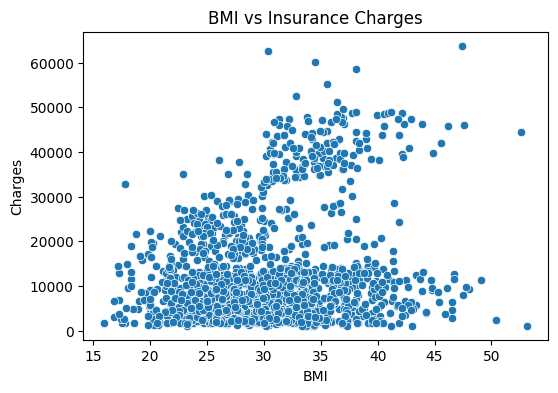

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["bmi"], y=df["charges"])
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

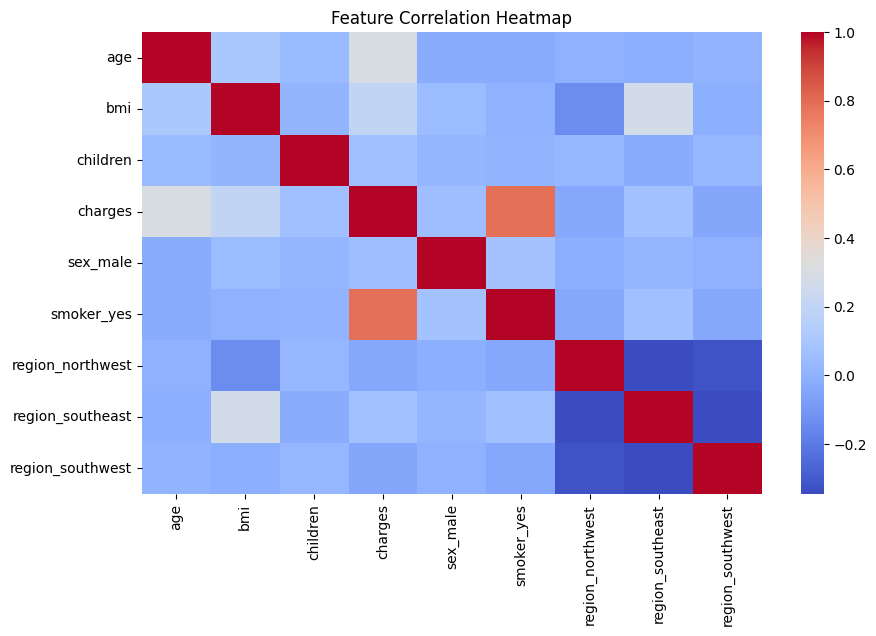

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: 0.7835929767120722


In [ ]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, dt_pred))

Decision Tree R2: 0.7090288165060088


In [ ]:
rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train)
rf_reg_pred = rf_reg.predict(X_test)
print("Random Forest R2:", r2_score(y_test, rf_reg_pred))

Random Forest R2: 0.8661081694357501


In [ ]:
df["high_cost"] = (df["charges"] > df["charges"].median()).astype(int)

In [ ]:
X_clf = df.drop(["charges", "high_cost"], axis=1)
y_clf = df["high_cost"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
log = LogisticRegression()
log.fit(X_train, y_train)
log_pred = log.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.914179104477612


In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9029850746268657


In [ ]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
rf_clf_pred = rf_clf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_clf_pred))

Random Forest Accuracy: 0.9365671641791045


In [ ]:
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9402985074626866


/tmp/ipykernel_2787/413463929.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette="viridis")


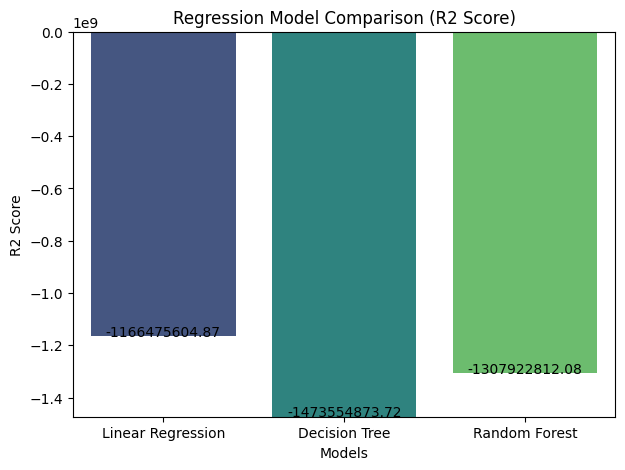

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ["Linear Regression", "Decision Tree", "Random Forest"]

scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_reg_pred)
]

plt.figure(figsize=(7,5))

# IMPORTANT FIX: use explicit data format
sns.barplot(x=models, y=scores, palette="viridis")

plt.title("Regression Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.ylim(min(scores) - 0.1, 1)  # dynamic scaling (IMPORTANT FIX)

# show values on bars (VERY IMPORTANT for clarity)
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

/tmp/ipykernel_2787/3007940492.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette="coolwarm")


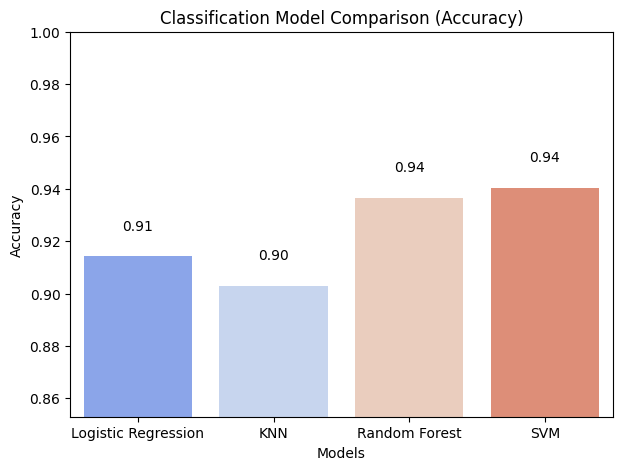

In [ ]:
print("\n========= FINAL RESULT =========\n")

print("📈 REGRESSION RESULTS")
print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Decision Tree R2:", r2_score(y_test, dt_pred))
print("Random Forest R2:", r2_score(y_test, rf_reg_pred))

print("\n🟢 CLASSIFICATION RESULTS")
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_clf_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\n🏆 BEST MODEL:")
print("Regression → Random Forest Regressor")
print("Classification → Random Forest Classifier")

print("\n=================================\n")


========= FINAL RESULT =========

📈 REGRESSION RESULTS
Linear Regression R2: -1166475604.8665833
Decision Tree R2: -1473554873.715878
Random Forest R2: -1307922812.08353

🟢 CLASSIFICATION RESULTS
Logistic Regression Accuracy: 0.914179104477612
KNN Accuracy: 0.9029850746268657
Random Forest Accuracy: 0.9365671641791045
SVM Accuracy: 0.9402985074626866

🏆 BEST MODEL:
Regression → Random Forest Regressor
Classification → Random Forest Classifier


